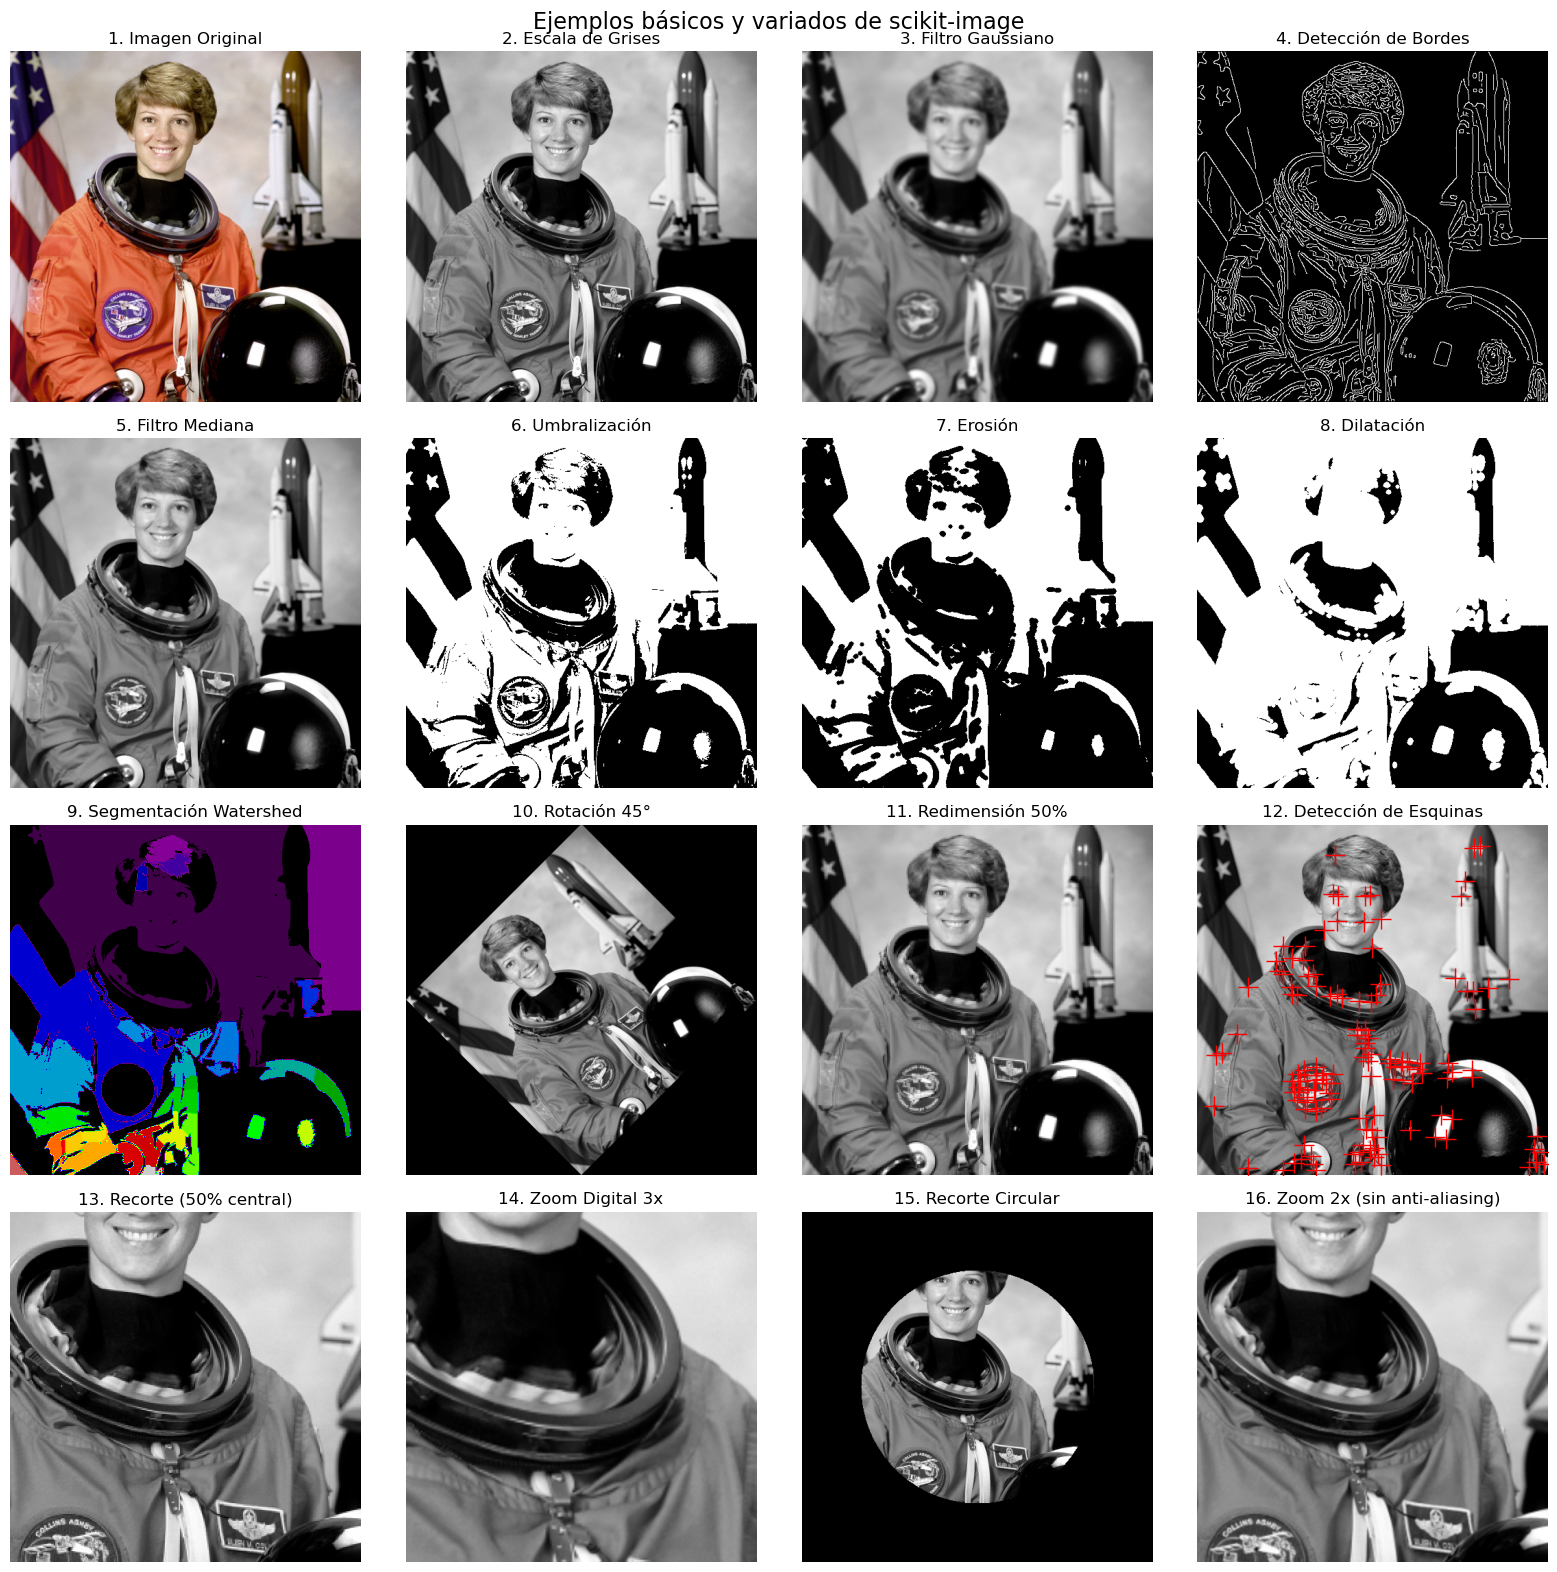

=== INFORMACIÓN ADICIONAL ===
Dimensiones imagen original: (512, 512, 3)
Dimensiones escala de grises: (512, 512)
Número de esquinas detectadas: 135
Umbral calculado automáticamente: 0.389
Número de regiones en watershed: 32
Dimensiones del recorte: (256, 256)
Dimensiones del zoom: (512, 512)
Radio del recorte circular: 170 píxeles

=== ANÁLISIS DE OBJETOS ===
Número de objetos encontrados: 155
Objeto 1: Área = 198.0, Perímetro = 67.6
Objeto 2: Área = 150704.0, Perímetro = 13065.2
Objeto 3: Área = 114.0, Perímetro = 44.4

=== IMÁGENES DE PRUEBA DISPONIBLES ===
Puedes cambiar 'data.astronaut()' por:
  data.astronaut()
  data.camera()
  data.checkerboard()
  data.clock()
  data.coffee()
  data.coins()
  data.horse()
  data.moon()
  data.page()
  data.rocket()
  data.text()


In [ ]:
from skimage import data, filters, feature, morphology, segmentation, measure, transform, color
import matplotlib.pyplot as plt
import numpy as np

# Crear una figura grande para mostrar todos los ejemplos
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Ejemplos básicos y variados de scikit-image', fontsize=16)

# 1. Imagen original
img = data.astronaut()
axes[0,0].imshow(img)
axes[0,0].set_title('1. Imagen Original')
axes[0,0].axis('off')

# 2. Conversión a escala de grises
gray = color.rgb2gray(img)
axes[0,1].imshow(gray, cmap='gray')
axes[0,1].set_title('2. Escala de Grises')
axes[0,1].axis('off')

# 3. Filtro de desenfoque
blur = filters.gaussian(gray, sigma=2)
axes[0,2].imshow(blur, cmap='gray')
axes[0,2].set_title('3. Filtro Gaussiano')
axes[0,2].axis('off')

# 4. Detección de bordes
edges = feature.canny(gray, sigma=1)
axes[0,3].imshow(edges, cmap='gray')
axes[0,3].set_title('4. Detección de Bordes')
axes[0,3].axis('off')

# 5. Filtro de mediana (reduce ruido)
median = filters.median(gray)
axes[1,0].imshow(median, cmap='gray')
axes[1,0].set_title('5. Filtro Mediana')
axes[1,0].axis('off')

# 6. Umbralización (binarización)
threshold = filters.threshold_otsu(gray)
binary = gray > threshold
axes[1,1].imshow(binary, cmap='gray')
axes[1,1].set_title('6. Umbralización')
axes[1,1].axis('off')

# 7. Operaciones morfológicas (erosión)
eroded = morphology.erosion(binary, morphology.disk(3))
axes[1,2].imshow(eroded, cmap='gray')
axes[1,2].set_title('7. Erosión')
axes[1,2].axis('off')

# 8. Operaciones morfológicas (dilatación)
dilated = morphology.dilation(binary, morphology.disk(3))
axes[1,3].imshow(dilated, cmap='gray')
axes[1,3].set_title('8. Dilatación')
axes[1,3].axis('off')

# 9. Segmentación por watershed
eroded_for_watershed = morphology.binary_erosion(binary, morphology.disk(10))
markers = measure.label(eroded_for_watershed)
watershed_result = segmentation.watershed(~binary, markers, mask=binary)
axes[2,0].imshow(watershed_result, cmap='nipy_spectral')
axes[2,0].set_title('9. Segmentación Watershed')
axes[2,0].axis('off')

# 10. Rotación de imagen
rotated = transform.rotate(gray, angle=45, resize=True)
axes[2,1].imshow(rotated, cmap='gray')
axes[2,1].set_title('10. Rotación 45°')
axes[2,1].axis('off')

# 11. Cambio de tamaño
resized = transform.resize(gray, (gray.shape[0]//2, gray.shape[1]//2))
axes[2,2].imshow(resized, cmap='gray')
axes[2,2].set_title('11. Redimensión 50%')
axes[2,2].axis('off')

# 12. Detección de esquinas de Harris
corners = feature.corner_harris(gray)
axes[2,3].imshow(gray, cmap='gray')
coords = feature.corner_peaks(corners, min_distance=5, threshold_rel=0.02)
axes[2,3].plot(coords[:, 1], coords[:, 0], '+r', markersize=15)
axes[2,3].set_title('12. Detección de Esquinas')
axes[2,3].axis('off')

# 13. Recorte de región específica
h, w = gray.shape
crop_y1, crop_y2 = h//4, 3*h//4
crop_x1, crop_x2 = w//4, 3*w//4
cropped = gray[crop_y1:crop_y2, crop_x1:crop_x2]
axes[3,0].imshow(cropped, cmap='gray')
axes[3,0].set_title('13. Recorte (50% central)')
axes[3,0].axis('off')

# 14. Zoom digital (interpolación)
zoom_region = gray[h//3:2*h//3, w//3:2*w//3]
zoomed = transform.resize(zoom_region, gray.shape, anti_aliasing=True)
axes[3,1].imshow(zoomed, cmap='gray')
axes[3,1].set_title('14. Zoom Digital 3x')
axes[3,1].axis('off')

# 15. Recorte circular (máscara)
center_y, center_x = h//2, w//2
radius = min(h, w)//3
y, x = np.ogrid[:h, :w]
mask_circle = (x - center_x)**2 + (y - center_y)**2 <= radius**2
circular_crop = gray.copy()
circular_crop[~mask_circle] = 0
axes[3,2].imshow(circular_crop, cmap='gray')
axes[3,2].set_title('15. Recorte Circular')
axes[3,2].axis('off')

# 16. Zoom con interpolación diferente
zoom_factor = 2.0
zoomed_bilinear = transform.rescale(
    gray,
    zoom_factor,
    anti_aliasing=False,
    mode='constant'   # 👈 se elimina multichannel
)
h_zoom, w_zoom = zoomed_bilinear.shape
start_h = (h_zoom - h)//2
start_w = (w_zoom - w)//2
zoomed_final = zoomed_bilinear[start_h:start_h+h, start_w:start_w+w]
axes[3,3].imshow(zoomed_final, cmap='gray')
axes[3,3].set_title('16. Zoom 2x (sin anti-aliasing)')
axes[3,3].axis('off')

plt.tight_layout()
plt.show()

# Información adicional
print("=== INFORMACIÓN ADICIONAL ===")
print(f"Dimensiones imagen original: {img.shape}")
print(f"Dimensiones escala de grises: {gray.shape}")
print(f"Número de esquinas detectadas: {len(coords)}")
print(f"Umbral calculado automáticamente: {threshold:.3f}")
print(f"Número de regiones en watershed: {np.max(watershed_result)}")
print(f"Dimensiones del recorte: {cropped.shape}")
print(f"Dimensiones del zoom: {zoomed.shape}")
print(f"Radio del recorte circular: {radius} píxeles")

# Análisis de objetos
labeled_img = measure.label(binary)
props = measure.regionprops(labeled_img)

print(f"\n=== ANÁLISIS DE OBJETOS ===")
print(f"Número de objetos encontrados: {len(props)}")
if len(props) > 0:
    for i, prop in enumerate(props[:3]):
        print(f"Objeto {i+1}: Área = {prop.area}, Perímetro = {prop.perimeter:.1f}")

# Diferentes imágenes de prueba disponibles
print(f"\n=== IMÁGENES DE PRUEBA DISPONIBLES ===")
test_images = ['astronaut', 'camera', 'checkerboard', 'clock', 'coffee',
               'coins', 'horse', 'moon', 'page', 'rocket', 'text']
print("Puedes cambiar 'data.astronaut()' por:")
for img_name in test_images:
    print(f"  data.{img_name}()")
